In [15]:
import jax.numpy as jnp 
import numpy as np 
import json 
import jax

_NPZ_PATH = 'data/snicar_emulator.npz'

def _load_emulator(path):
    data = np.load(path, allow_pickle=False)
    meta = json.loads(str(data['metadata']))

    weights, biases = [], []
    i = 0
    while f'weights_{i}' in data:
        weights.append(jnp.array(data[f'weights_{i}'], dtype=jnp.float32))
        biases.append(jnp.array(data[f'biases_{i}'], dtype=jnp.float32))
        i += 1

    return {
        'weights':        weights,
        'biases':         biases,
        'pca_components': jnp.array(data['pca_components'], dtype=jnp.float32),
        'pca_mean':       jnp.array(data['pca_mean'],       dtype=jnp.float32),
        'input_min':      jnp.array(data['input_min'],      dtype=jnp.float32),
        'input_max':      jnp.array(data['input_max'],      dtype=jnp.float32),
        'flx_slr':        jnp.array(data['flx_slr'],        dtype=jnp.float32),
        'param_names':    meta['param_names'],
    }

_emu = _load_emulator(_NPZ_PATH)
_flx_slr_norm = _emu['flx_slr'] / _emu['flx_slr'].sum()  # normalized for BBA


def _forward(x):
    """Pure-JAX MLP + PCA reconstruction for a single input vector (n_params,)."""
    for i, (W, b) in enumerate(zip(_emu['weights'], _emu['biases'])):
        x = x @ W + b
        if i < len(_emu['weights']) - 1:
            x = jnp.maximum(x, 0.0)  # ReLU
    spectral = x @ _emu['pca_components'] + _emu['pca_mean']
    return jnp.clip(spectral, 0.0, 1.0)  # (480,)

In [16]:
def emulator(ldensity, lgrainsize, lgrainshape, 
                  lBC, lOC, ldust,
                  solzen, direct):


    solzen = jnp.array([int(solzen)])
    direct = jnp.array([float(direct)])

    # stack inputs
    X = jnp.stack([lgrainsize, ldensity, lBC, lOC, ldust,
                   solzen, direct, lgrainshape], axis=1)  # (N, 8)

    # min-max scale to [0, 1]
    X = (X - _emu['input_min']) / (_emu['input_max'] - _emu['input_min'] + 1e-30)
    X = jnp.clip(X, 0.0, 1.0)

    # run emulator for each grid point → spectral albedo (N, 480)
    spectral = jax.vmap(_forward)(X)

    # broadband albedo weighted by solar spectrum
    albedo = jnp.sum(spectral * _flx_slr_norm, axis=1)

    return albedo


In [18]:
lheight = np.array([0.05]) # , 0.1, 0.25, 0.6])
ldensity = np.array([300]) # , 500, 500, 500])
lBC = np.array([1]) # , 10, 10, 10])
lOC = np.array([1]) # , 20, 20, 20])
ldust = np.array([1]) # , 200, 200, 200])
lgrainsize = np.array([60]) # , 750, 750, 500])
lgrainshape = np.array([0]) # , 2, 2, 2])
solzen = 50
direct = True

emulator(ldensity, lgrainsize, lgrainshape,
         lBC, lOC, ldust, solzen, direct)

Array([0.83580744], dtype=float32)

In [65]:
# data = np.load(f'../SNICAR/all_samples/snicar_train.npz')
# data_columns = ['grainsize','density','height','BC','OC','dust','grainshape', 'solar_zenith','direct']
# N_PARAMS_PER_LAYER = 7
# N_LAYERS = 4

# data_means = []
# for i in range(N_PARAMS_PER_LAYER):
#     layer_cols = [i + j * N_PARAMS_PER_LAYER for j in range(N_LAYERS)]  # e.g. grainsize: [0, 7, 14, 21]
#     data_means.append(np.mean(data['X'][:, layer_cols], axis=1))

# data_means.append(data['X'][:, 28])  # solar_zenith
# data_means.append(data['X'][:, 29])  # direct

# df = pd.DataFrame({data_columns[i]: data_means[i] for i in range(len(data_columns))})

# df['albedo'] = data['y']
# df

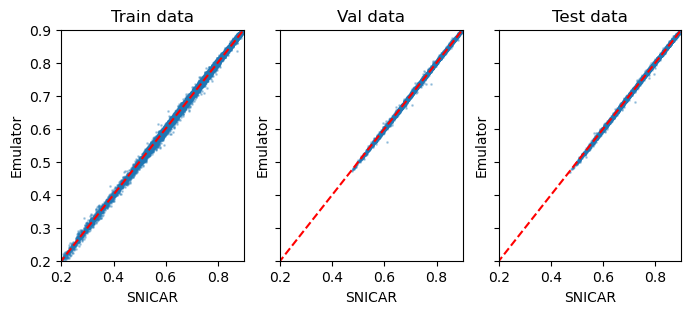

In [66]:
import numpy as np 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(8, 3))

for split, ax in zip(['train','val','test'], axes):
    data  = np.load(f'../SNICAR/snicar_data/snicar_{split}.npz')
    X, y = jnp.array(data['X']), jnp.array(data['y'])
    y_pred = jax.vmap(model)((X - mu) / sigma)

    ax.scatter(y, y_pred, s=1, alpha=0.3)
    ax.plot([0,1],[0,1],'r--')
    ax.set_xlabel('SNICAR')
    ax.set_ylabel('Emulator')
    ax.set_xlim(0.2, 0.9)
    ax.set_ylim(0.2, 0.9)
    ax.set_title(split.capitalize() + ' data')
plt.show()

In [ ]:


y_pred = jax.vmap(model)((X - mu) / sigma)
print(y_pred)